In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cosine as cosine_distance
import warnings
warnings.filterwarnings('ignore') 

# Data Preprocessing

In [2]:
# Step 1: Load the data
columns = ['user_id', 'item_id', 'rating', 'timestamp']
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=columns)

In [3]:
ratings.shape

(100000, 4)

In [4]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [5]:
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


# User Profile Similarity Analysis

In [6]:
# Step 2: Create a utility matrix (users x items)
utility_matrix = ratings.pivot(index='user_id', columns='item_id', values='rating')

# Step 3: Center the data by subtracting each user's mean rating
centered_matrix = utility_matrix.sub(utility_matrix.mean(axis=1), axis=0)

# Step 4: Get user profiles for user 200 and 15
user_200_profile = centered_matrix.loc[200]
user_15_profile = centered_matrix.loc[15]

# Step 5: Extract the centered vector for item 95 (all users’ opinions on item 95)
movie_95_profile = centered_matrix[95]

# Step 6: Align the vectors (only users/items with non-NaN values for fair comparison)
def aligned_vectors(user_profile, item_profile):
    common_index = user_profile.index.intersection(item_profile.index)
    user_vec = user_profile[common_index]
    item_vec = item_profile[common_index]
    mask = ~user_vec.isna() & ~item_vec.isna()
    return user_vec[mask], item_vec[mask]

# Compare user 200 to movie 95
u200_vec, m95_vec_200 = aligned_vectors(user_200_profile, movie_95_profile)
cos_sim_200 = cosine_similarity([u200_vec], [m95_vec_200])[0, 0]
cos_dist_200 = cosine_distance(u200_vec, m95_vec_200)

# Compare user 15 to movie 95
u15_vec, m95_vec_15 = aligned_vectors(user_15_profile, movie_95_profile)
cos_sim_15 = cosine_similarity([u15_vec], [m95_vec_15])[0, 0]
cos_dist_15 = cosine_distance(u15_vec, m95_vec_15)

# Print results
print(f"User 200 <-> Movie 95: Cosine Similarity = {cos_sim_200:.4f}, Cosine Distance = {cos_dist_200:.4f}")
print(f"User  15 <-> Movie 95: Cosine Similarity = {cos_sim_15:.4f}, Cosine Distance = {cos_dist_15:.4f}")

# Decide recommendation
if cos_sim_200 > cos_sim_15:
    print("Movie 95 would more likely be recommended to User 200.")
else:
    print("Movie 95 would more likely be recommended to User 15.")

User 200 <-> Movie 95: Cosine Similarity = 0.0890, Cosine Distance = 0.9110
User  15 <-> Movie 95: Cosine Similarity = 0.1305, Cosine Distance = 0.8695
Movie 95 would more likely be recommended to User 15.


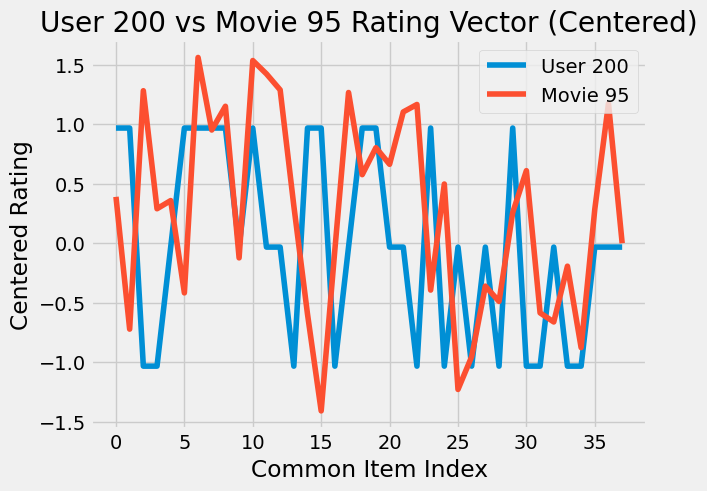

In [8]:
plt.plot(u200_vec.values, label='User 200')
plt.plot(m95_vec_200.values, label='Movie 95')
plt.title('User 200 vs Movie 95 Rating Vector (Centered)')
plt.xlabel('Common Item Index')
plt.ylabel('Centered Rating')
plt.legend()
plt.show()

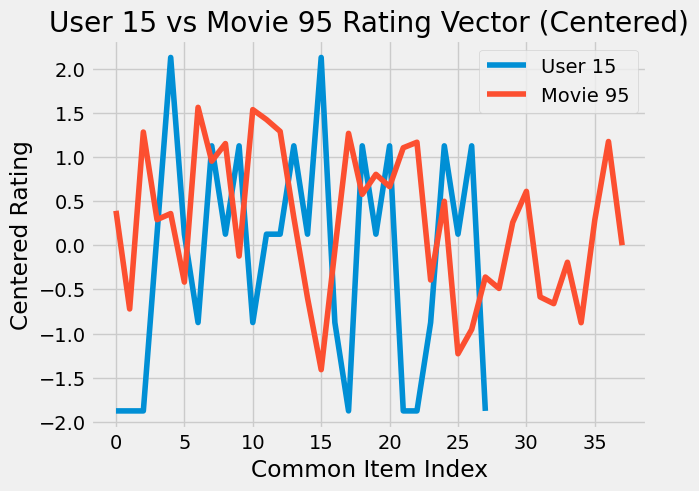

In [11]:
plt.plot(u15_vec.values, label='User 15')
plt.plot(m95_vec_200.values, label='Movie 95')
plt.title('User 15 vs Movie 95 Rating Vector (Centered)')
plt.xlabel('Common Item Index')
plt.ylabel('Centered Rating')
plt.legend()
plt.show()

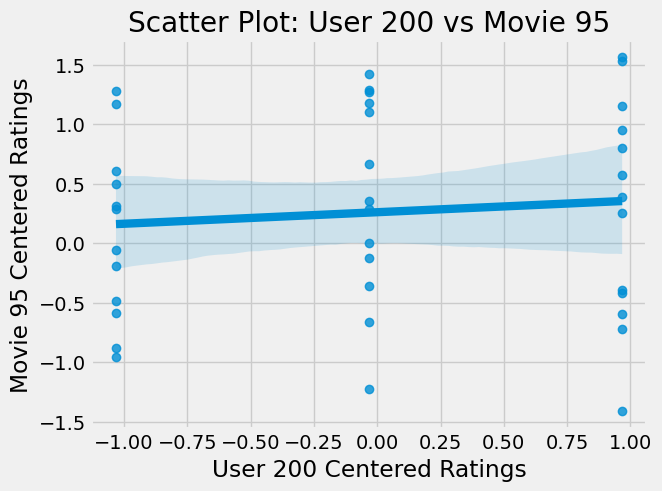

In [9]:
sns.regplot(x=u200_vec, y=m95_vec_200)
plt.xlabel("User 200 Centered Ratings")
plt.ylabel("Movie 95 Centered Ratings")
plt.title("Scatter Plot: User 200 vs Movie 95")
plt.show()

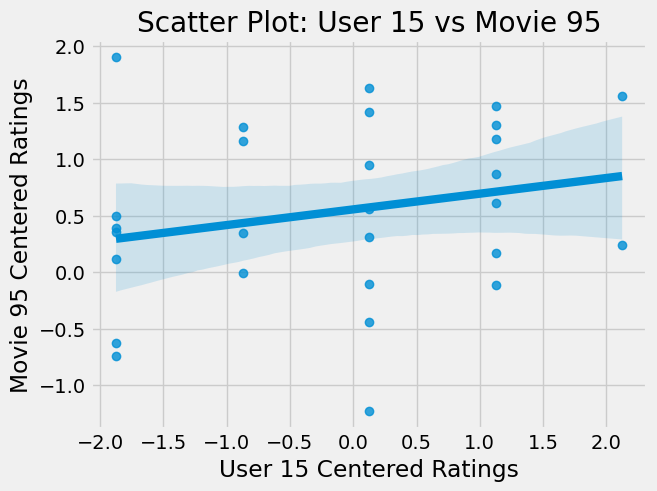

In [13]:
sns.regplot(x=u15_vec, y=m95_vec_15)
plt.xlabel("User 15 Centered Ratings")
plt.ylabel("Movie 95 Centered Ratings")
plt.title("Scatter Plot: User 15 vs Movie 95")
plt.show()